In [ ]:
# Mount into drive

from google.colab import drive

drive.mount("/content/drive")
#! ls /content/drive
%cd '/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB'

!pip install -r requirements_jing.txt


Mounted at /content/drive
/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
%load_ext autoreload
%autoreload 2


In [ ]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys
import yaml
from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset, LOBLazySequenceDataset
from training.trainer import Trainer, Config

In [ ]:
print(os.getcwd())

In [ ]:

with open("configs/tlob.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [ ]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

import pprint  # Import the pprint module
pp = pprint.PrettyPrinter(indent=4)  # Create a PrettyPrinter object
pp.pprint(config_dict)              # Pretty print config_dict

In [ ]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000107
Shape after label creation and NaN drop: (4817723, 12)
Label distribution:
label
1    0.447960
2    0.278496
0    0.273544
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

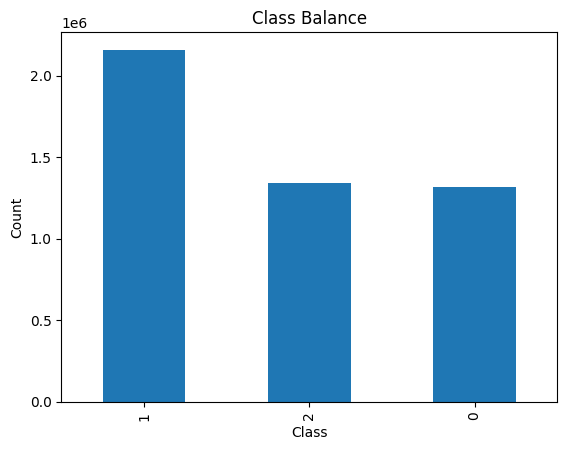

In [ ]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372406, Val=722658, Test=722659


2810

In [ ]:
train_df.head()

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
100,70292.523438,70292.203125,70292.53125,70295.59375,0.006694,0.021339,0.081937,0.019718,70292.53125,0.007812,-0.567678,2
101,70292.523438,70292.203125,70292.53125,70295.59375,0.006694,0.021339,0.081937,0.019718,70292.53125,0.007812,-0.567678,2
102,70292.523438,70292.203125,70292.53125,70295.59375,0.006694,0.021339,0.081937,0.019718,70292.53125,0.007812,-0.567678,2
103,70292.523438,70292.203125,70292.53125,70295.59375,0.006694,0.021339,0.081937,0.019718,70292.53125,0.007812,-0.567678,2
104,70292.523438,70292.203125,70292.53125,70295.59375,0.006694,0.021339,0.081937,0.019718,70292.53125,0.007812,-0.567678,2


In [ ]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (11): ['b0', 'b1', 'a0', 'a1', 'bq0', 'bq1', 'aq0', 'aq1', 'mid_price', 'spread']...
Normalization applied.


0

In [ ]:
train_df_norm.head()

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
100,-0.549906,-0.539937,-0.490928,-0.49148,-0.163078,-0.199791,-0.033905,-0.068456,-0.522074,0.302583,-0.825737,2
101,-0.549906,-0.539937,-0.490928,-0.49148,-0.163078,-0.199791,-0.033905,-0.068456,-0.522074,0.302583,-0.825737,2
102,-0.549906,-0.539937,-0.490928,-0.49148,-0.163078,-0.199791,-0.033905,-0.068456,-0.522074,0.302583,-0.825737,2
103,-0.549906,-0.539937,-0.490928,-0.49148,-0.163078,-0.199791,-0.033905,-0.068456,-0.522074,0.302583,-0.825737,2
104,-0.549906,-0.539937,-0.490928,-0.49148,-0.163078,-0.199791,-0.033905,-0.068456,-0.522074,0.302583,-0.825737,2


In [ ]:
config.sequence_length = 100

In [ ]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float32).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float32).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float32).values

T = config.sequence_length
stride=config.stride_length
# Toggle whether to use lazy (on-the-fly) sliding windows or pre-built sequences
use_lazy_sequences = True

if use_lazy_sequences:
    train_dataset = LOBLazySequenceDataset(
        features=X_train_features,
        labels=y_train_series,
        seq_len=T,
        stride=stride,
        device=device
    )

    val_dataset = LOBLazySequenceDataset(
        features=X_val_features,
        labels=y_val_series,
        seq_len=T,
        stride=stride,
        device=device
    )

    test_dataset = LOBLazySequenceDataset(
        features=X_test_features,
        labels=y_test_series,
        seq_len=T,
        stride=stride,
        device=device
    )
else:
    X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision)
    X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision)
    X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision)

    train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
    val_dataset   = LOBSequenceDataset(X_val_seq,   y_val_seq,   device=device)
    test_dataset  = LOBSequenceDataset(X_test_seq,  y_test_seq,  device=device)


del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

0

In [ ]:
# # --- 5. Create Datasets & DataLoaders ---
# train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
# val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
# test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

# #train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True) # num_workers/pin_memory optional
# #val_loader = DataLoader(val_dataset, batch_size=config.train.batch_size, shuffle=False)
# #test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False)
# # gc.collect()

In [ ]:
print(config.model.type)

tlob_model


In [ ]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB/training/trainer.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None


One batch shape: torch.Size([512, 11, 100])

Datasets and DataLoaders created.
Number of training batches: 659
Number of validation batches: 142
Number of testing batches: 142
Input Size: torch.Size([512, 11, 100])


In [ ]:
from experiment_runner.experiment_runner import run_single_trial, run_parameter_sweep, orchestrate_experiment
from experiment_runner.experiment_runner import save_df
base_dir = 'results/tlob/'
trial_name = 'test_tlob_single_trial_10h'
trainer, training_history, final_results = run_single_trial(trial_config=config,
                           train_dataset=train_dataset,
                           val_dataset=val_dataset,
                           test_dataset=test_dataset,
                           device=torch.device(device),
                           base_dir=base_dir,
                           trial_name=trial_name,
                           verbose=True)

Created experiment directory: results/tlob/test_tlob_single_trial_vis

--- Running Trial: test_tlob_single_trial_vis ---
Config: {'data_path': 'data/coinbase_book_2024-10-29_2024-11-11', 'num_files': None, 'precision': None, 'clean_strategy': 'dropna', 'num_levels_features': 2, 'label_price_type': 'simple_midpoint', 'label_price_levels': 1, 'label_price_col': None, 'label_method': 'tlob', 'label_k': 100, 'label_h': 100, 'label_alpha': 'auto', 'verbose': True, 'sequence_length': 100, 'stride_length': 10, 'output_path': 'results/', 'output_name': 'tlob', 'split_fractions': <training.trainer.Config object at 0x7a78d7e88350>, 'seed': 42, 'train': <training.trainer.Config object at 0x7a79fd0d6ad0>, 'model': <training.trainer.Config object at 0x7a79fd368510>, 'loss': None, 'optimizer': <training.trainer.Config object at 0x7a79fc750450>, 'scheduler': <training.trainer.Config object at 0x7a788b163990>}
Configuration saved to results/tlob/test_tlob_single_trial_vis/trial_config.yaml
One batch s

/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB/training/trainer.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None
/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB/training/trainer.py:283: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch[Batch]: [1][0/659]	Avg_Loss 1.092 (1.092)	 Time 0.301 (0.301)	
Epoch[Batch]: [1][65/659]	Avg_Loss 0.930 (1.001)	 Time 0.055 (0.060)	
Epoch[Batch]: [1][130/659]	Avg_Loss 0.874 (0.947)	 Time 0.055 (0.058)	
Epoch[Batch]: [1][195/659]	Avg_Loss 0.867 (0.922)	 Time 0.055 (0.057)	
Epoch[Batch]: [1][260/659]	Avg_Loss 0.860 (0.906)	 Time 0.056 (0.056)	
Epoch[Batch]: [1][325/659]	Avg_Loss 0.866 (0.896)	 Time 0.056 (0.056)	
Epoch[Batch]: [1][390/659]	Avg_Loss 0.849 (0.888)	 Time 0.055 (0.056)	
Epoch[Batch]: [1][455/659]	Avg_Loss 0.820 (0.881)	 Time 0.056 (0.056)	
Epoch[Batch]: [1][520/659]	Avg_Loss 0.847 (0.876)	 Time 0.055 (0.056)	
Epoch[Batch]: [1][585/659]	Avg_Loss 0.879 (0.872)	 Time 0.056 (0.056)	
Epoch[Batch]: [1][650/659]	Avg_Loss 0.793 (0.868)	 Time 0.056 (0.056)	
Epoch 1/20 — Train loss: 0.8677 — Train F₁: 0.5810


/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB/training/trainer.py:236: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 0.8705 — Val F₁: 0.6023
Epoch finished in 67.04436784399991 seconds
  ↳ New best model (val_loss=0.8705), checkpoint saved.
Epoch[Batch]: [2][0/659]	Avg_Loss 0.840 (0.868)	 Time 0.056 (0.056)	
Epoch[Batch]: [2][65/659]	Avg_Loss 0.794 (0.864)	 Time 0.056 (0.056)	
Epoch[Batch]: [2][130/659]	Avg_Loss 0.852 (0.861)	 Time 0.055 (0.056)	
Epoch[Batch]: [2][195/659]	Avg_Loss 0.817 (0.859)	 Time 0.056 (0.056)	
Epoch[Batch]: [2][260/659]	Avg_Loss 0.829 (0.856)	 Time 0.055 (0.056)	
Epoch[Batch]: [2][325/659]	Avg_Loss 0.798 (0.854)	 Time 0.056 (0.056)	
Epoch[Batch]: [2][390/659]	Avg_Loss 0.822 (0.852)	 Time 0.055 (0.056)	
Epoch[Batch]: [2][455/659]	Avg_Loss 0.841 (0.850)	 Time 0.056 (0.056)	
Epoch[Batch]: [2][520/659]	Avg_Loss 0.807 (0.849)	 Time 0.056 (0.056)	
Epoch[Batch]: [2][585/659]	Avg_Loss 0.825 (0.847)	 Time 0.055 (0.056)	
Epoch[Batch]: [2][650/659]	Avg_Loss 0.838 (0.845)	 Time 0.055 (0.056)	
Epoch 2/20 — Train loss: 0.8452 — Train F₁: 0.6173
  ↳ Val loss: 0.8578 — Val F₁: 0.

In [ ]:
training_history

{'epochs': array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20.]),
 'train_loss': [0.7483389115982108,
  0.730589586913525,
  0.7218286263151387,
  0.7160728611113631,
  0.7116476327573729,
  0.7078675263050453,
  0.7040608035514148,
  0.7007225674013424],
 'train_score': [array(0.66205174, dtype=float32),
  array(0.68391323, dtype=float32),
  array(0.6882037, dtype=float32),
  array(0.6907186, dtype=float32),
  array(0.69290733, dtype=float32),
  array(0.6952955, dtype=float32),
  array(0.69874096, dtype=float32),
  array(0.7002256, dtype=float32)],
 'val_loss': [0.7976934658557712,
  0.7758748466199639,
  0.7697363758873184,
  0.7744007773354663,
  0.7704218149965861,
  0.7738016197114008,
  0.7746728605541398,
  0.7853836755055145],
 'val_score': [array(0.6440394, dtype=float32),
  array(0.66205025, dtype=float32),
  array(0.6663408, dtype=float32),
  array(0.66225135, dtype=float32),
  array(0.66627365, dtype=float32),
  

In [ ]:
final_results

{'epochs': 20,
 'train_loss': 0.7007225674013424,
 'train_score': 0.7002255916595459,
 'val_loss': 0.7853836755055145,
 'val_score': 0.6597793102264404,
 'test_loss': 0.724670360842644,
 'test_score': 0.6812628507614136}

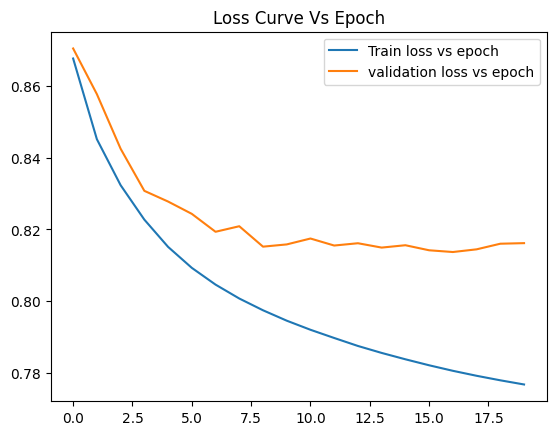

In [ ]:
pd.Series(training_history['train_loss']).plot(label="Train loss vs epoch")
pd.Series(training_history['val_loss']).plot(label="validation loss vs epoch")
plt.title("Loss Curve Vs Epoch")
plt.legend()
plt.show()

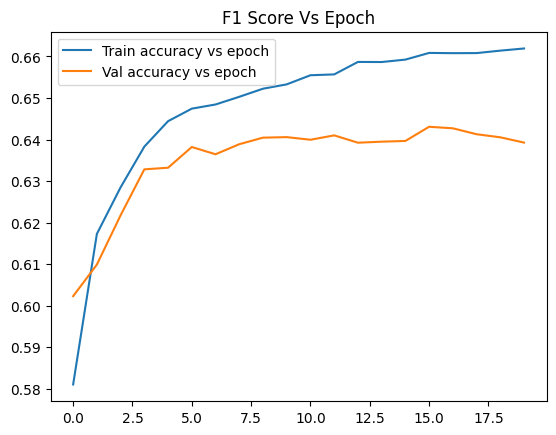

In [ ]:
pd.Series((training_history['train_score'])).astype('float').plot(label="Train accuracy vs epoch")
pd.Series((training_history['val_score'])).astype('float').plot(label="Val accuracy vs epoch")
plt.title("F1 Score Vs Epoch")
plt.legend()
plt.show()

In [ ]:
pd.Series(training_history['val_score'])

,0
0,0.6440394
1,0.66205025
2,0.6663408
3,0.66225135
4,0.66627365
5,0.6651196
6,0.6656637
7,0.6597793


In [ ]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))
checkpoint = torch.load('results/tlob/test_tlob_single_trial_vis/tlob_best_with_test_score.pt', map_location=device)
trainer.model.load_state_dict(checkpoint)
trainer.model.eval()

One batch shape: torch.Size([512, 11, 100])

Datasets and DataLoaders created.
Number of training batches: 659
Number of validation batches: 142
Number of testing batches: 142
Input Size: torch.Size([512, 11, 100])


TLOB(
  (fc1): Linear(in_features=11, out_features=3, bias=True)
  (relu): ReLU()
  (input_preprocessor): Sequential(
    (0): BiN()
    (1): Rearrange('b f s -> b s f')
    (2): Linear(in_features=11, out_features=32, bias=True)
  )
  (layers): ModuleList(
    (0): TransformerLayer(
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (qkv): ComputeQKV(
        (q): Linear(in_features=32, out_features=64, bias=True)
        (k): Linear(in_features=32, out_features=64, bias=True)
        (v): Linear(in_features=32, out_features=64, bias=True)
      )
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (mlp): MLP(
        (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (fc): Linear(in_features=32, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=32, bias=True)
        (gelu): GELU(approximate='none')
      )
     

In [ ]:
checkpoint.keys()

odict_keys(['pos_encoder', 'fc1.weight', 'fc1.bias', 'input_preprocessor.0.B1', 'input_preprocessor.0.l1', 'input_preprocessor.0.B2', 'input_preprocessor.0.l2', 'input_preprocessor.0.y1', 'input_preprocessor.0.y2', 'input_preprocessor.2.weight', 'input_preprocessor.2.bias', 'layers.0.norm.weight', 'layers.0.norm.bias', 'layers.0.qkv.q.weight', 'layers.0.qkv.q.bias', 'layers.0.qkv.k.weight', 'layers.0.qkv.k.bias', 'layers.0.qkv.v.weight', 'layers.0.qkv.v.bias', 'layers.0.attention.in_proj_weight', 'layers.0.attention.in_proj_bias', 'layers.0.attention.out_proj.weight', 'layers.0.attention.out_proj.bias', 'layers.0.mlp.layer_norm.weight', 'layers.0.mlp.layer_norm.bias', 'layers.0.mlp.fc.weight', 'layers.0.mlp.fc.bias', 'layers.0.mlp.fc2.weight', 'layers.0.mlp.fc2.bias', 'layers.0.proj.weight', 'layers.0.proj.bias', 'layers.1.norm.weight', 'layers.1.norm.bias', 'layers.1.qkv.q.weight', 'layers.1.qkv.q.bias', 'layers.1.qkv.k.weight', 'layers.1.qkv.k.bias', 'layers.1.qkv.v.weight', 'layers.

In [ ]:
trainer.visualize_attention(trainer.model)

In [ ]:
import kaleido

In [ ]:
!!pip install -U kaleido

['Requirement already satisfied: kaleido in /usr/local/lib/python3.11/dist-packages (0.2.1)']